# 01 · Data quality

**Viral to Value** — does Instagram virality translate into durable customer economics?

This notebook loads the raw star-schema tables, checks types, keys, referential integrity,
value ranges and the observation window, and writes the processed tables used by every
later notebook.

> The dataset is **simulated** (see `docs/methodology.md`). Every check here is one you would run on
> real exports too: nothing below assumes the data is clean because we generated it.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from clean_data import load_raw, validate, process
import viz; viz.setup()
pd.set_option("display.width", 160, "display.max_columns", 40)

raw = load_raw(__import__("pathlib").Path("../data/raw"))
for name, df in raw.items():
    print(f"{name:<10} {df.shape[0]:>9,} rows  {df.shape[1]:>2} cols")

campaigns        120 rows  16 cols
customers     40,947 rows   7 cols
sessions     811,653 rows  10 cols
orders        79,590 rows  15 cols
products          40 rows   6 cols


## 1. Schema and types

In [2]:
for name, df in raw.items():
    print(f"\n── {name} ──")
    print(df.dtypes.to_string())


── campaigns ──
campaign_id                     str
campaign_date        datetime64[us]
campaign_name                   str
content_type                    str
campaign_type                   str
creator_tier                    str
featured_category               str
spend                       float64
discount_pct                  int64
reach                         int64
impressions                   int64
likes                         int64
comments                      int64
shares                        int64
saves                         int64
follower_gain                 int64

── customers ──
customer_id                        str
acquisition_date        datetime64[us]
acquisition_campaign               str
age_group                          str
region                             str
first_purchase_date     datetime64[us]
acquisition_device                 str

── sessions ──
session_id                     str
customer_id                    str
timestamp           datetime64[

In [3]:
raw["campaigns"].head(3)

,campaign_id,campaign_date,campaign_name,content_type,campaign_type,creator_tier,featured_category,spend,discount_pct,reach,impressions,likes,comments,shares,saves,follower_gain
0,IG_001,2025-01-08,Influencer Reel Jan-08,Reel,Influencer,Micro,Accessories,6998.22,10,231486,357286,10033,1316,2169,1783,996
1,IG_002,2025-01-11,Paid Amplification Reel Jan-11,Reel,Paid Amplification,Brand,T-shirts,20246.90,15,591157,949739,33375,3232,4288,4606,1041
2,IG_003,2025-01-11,Influencer Reel Jan-11,Reel,Influencer,Macro,Hoodies,24736.95,0,10191099,12976963,759994,66733,142638,30542,45336


In [4]:
raw["orders"].head(3)

,order_id,customer_id,order_date,product_id,quantity,gross_revenue,discount_amount,net_revenue,cogs,shipping_cost,payment_fee,refund_amount,refund_days,delivery_days,is_first_order
0,O0000001,C000001,2025-01-17,P020,1,32.46,3.25,29.21,6.63,5.57,1.15,0.0,NaN,8,1
1,O0000002,C000001,2025-03-09,P024,1,16.18,0.00,16.18,3.29,5.08,0.77,0.0,NaN,7,0
2,O0000003,C000002,2025-01-10,P020,1,32.46,3.25,29.21,6.63,5.55,1.15,0.0,NaN,7,1


## 2. Missing values

Only two columns are *expected* to be null: `sessions.customer_id` (anonymous visitors) and
`sessions.campaign_id` (non-campaign traffic), plus `orders.refund_days` when there was no refund.

In [5]:
nulls = {n: df.isna().mean().round(4)[lambda s: s > 0] for n, df in raw.items()}
pd.concat({k: v for k, v in nulls.items() if len(v)}).rename("share_null").to_frame()

share_null
sessions customer_id      0.8504
         campaign_id      0.0992
orders   refund_days      0.9048

## 3. Keys, referential integrity and accounting identities

`validate()` in `src/clean_data.py` checks: unique primary keys, every foreign key resolves,
`net_revenue = gross − discount`, refunds never exceed net revenue, no negative costs, exactly one
first order per customer, and no order dated before the customer's first purchase.

In [6]:
issues = validate(raw)
print("issues found:", issues if issues else "none — all checks passed")

issues found: none — all checks passed


## 4. Value ranges and distributions

In [7]:
c, o, s = raw["campaigns"], raw["orders"], raw["sessions"]
c[["spend", "discount_pct", "reach", "impressions", "likes", "comments", "shares", "saves", "follower_gain"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
spend,120.0,14140.5,14944.0,1371.7,4554.8,8885.9,15166.8,83249.4
discount_pct,120.0,6.9,8.4,0.0,0.0,0.0,15.0,30.0
reach,120.0,612668.5,1168488.4,2409.0,89254.0,282267.0,602532.8,10191099.0
impressions,120.0,848711.1,1549907.8,2933.0,130354.0,404761.5,896089.8,12976963.0
likes,120.0,37765.1,81843.5,141.0,5245.5,16617.0,33630.0,759994.0
comments,120.0,3029.9,7327.2,13.0,393.5,1074.0,2638.2,66733.0
shares,120.0,6717.2,20350.1,7.0,411.2,1394.5,3988.8,145458.0
saves,120.0,5399.5,11077.0,8.0,675.8,1723.0,5317.8,86250.0
follower_gain,120.0,3100.6,6316.7,4.0,262.2,1156.5,2662.8,45336.0


In [8]:
o[["quantity", "gross_revenue", "discount_amount", "net_revenue", "cogs", "shipping_cost", "payment_fee", "refund_amount", "delivery_days"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
quantity,79590.0,1.29,0.55,1.00,1.00,1.00,1.00,3.00
gross_revenue,79590.0,97.06,69.06,16.18,44.41,88.95,117.15,505.62
discount_amount,79590.0,5.08,9.79,0.00,0.00,0.00,7.28,126.41
net_revenue,79590.0,91.97,66.27,11.33,42.00,78.46,115.47,505.62
cogs,79590.0,40.04,35.82,3.29,13.93,33.39,46.57,270.00
shipping_cost,79590.0,6.10,0.90,4.90,5.43,5.95,6.44,9.30
payment_fee,79590.0,2.97,1.92,0.63,1.52,2.58,3.65,14.96
refund_amount,79590.0,9.23,35.87,0.00,0.00,0.00,0.00,505.62
delivery_days,79590.0,4.80,2.01,2.00,3.00,4.00,6.00,20.00


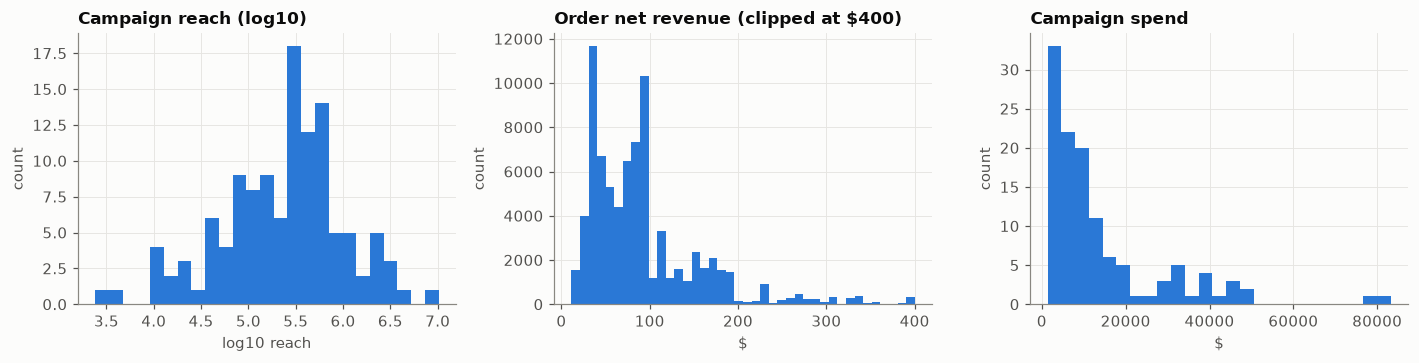

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
ax[0].hist(np.log10(c.reach), bins=25, color=viz.SERIES[0]); ax[0].set_title("Campaign reach (log10)"); ax[0].set_xlabel("log10 reach")
ax[1].hist(o.net_revenue.clip(upper=400), bins=40, color=viz.SERIES[0]); ax[1].set_title("Order net revenue (clipped at $400)"); ax[1].set_xlabel("$")
ax[2].hist(c.spend, bins=25, color=viz.SERIES[0]); ax[2].set_title("Campaign spend"); ax[2].set_xlabel("$")
for a in ax: a.set_ylabel("count")
plt.tight_layout(); plt.savefig("../images/01_distributions.png"); plt.show()

Reach is heavy-tailed on a log scale (a few campaigns reach millions, most reach tens or hundreds of thousands),
order values cluster by product category, and spend is right-skewed by macro/mega creator fees.
All three are the shapes you would expect from a real creator-led DTC brand.

## 5. Observation window

90-day metrics are only valid if **every** customer has at least 90 days of history. We check the gap
between the last acquisition date and the last order date.

In [10]:
cu = raw["customers"]
print("campaign dates  :", c.campaign_date.min().date(), "→", c.campaign_date.max().date())
print("acquisitions    :", cu.acquisition_date.min().date(), "→", cu.acquisition_date.max().date())
print("orders          :", o.order_date.min().date(), "→", o.order_date.max().date())
window = (o.order_date.max() - cu.acquisition_date.max()).days
print(f"days of history for the newest customer: {window}  (need ≥ 90) →", "OK" if window >= 90 else "TRUNCATED")

campaign dates  : 2025-01-08 → 2025-09-20
acquisitions    : 2025-01-08 → 2025-10-05
orders          : 2025-01-08 → 2026-01-30
days of history for the newest customer: 117  (need ≥ 90) → OK


## 6. Categorical sanity

In [11]:
for col in ["campaign_type", "content_type", "creator_tier", "featured_category"]:
    print(f"\n{col}:", c[col].value_counts().to_dict())
for col in ["age_group", "region", "acquisition_device"]:
    print(f"\n{col}:", cu[col].value_counts(normalize=True).round(3).to_dict())
print("\ntraffic_source:", s.traffic_source.value_counts().to_dict())


campaign_type: {'Influencer': 43, 'Paid Amplification': 20, 'Organic': 16, 'Product Drop': 15, 'Discount': 15, 'UGC': 11}

content_type: {'Reel': 63, 'Story': 22, 'Carousel': 20, 'Static Post': 11, 'Live': 4}

creator_tier: {'Brand': 66, 'Micro': 18, 'Mid': 17, 'Nano': 10, 'Macro': 7, 'Mega': 2}

featured_category: {'Hoodies': 34, 'T-shirts': 24, 'Limited Drops': 18, 'Sneakers': 16, 'Gymwear': 16, 'Accessories': 12}

age_group: {'21-24': 0.383, '18-20': 0.298, '25-27': 0.199, '28+': 0.121}

region: {'US-East': 0.218, 'US-West': 0.2, 'US-South': 0.159, 'UK': 0.122, 'US-Midwest': 0.102, 'EU': 0.099, 'CA': 0.062, 'AU': 0.039}

acquisition_device: {'mobile': 0.856, 'desktop': 0.111, 'tablet': 0.033}

traffic_source: {'instagram_campaign': 731147, 'direct': 24287, 'email': 16017, 'organic_search': 14246, 'instagram_organic': 13776, 'paid_social': 6491, 'sms': 5689}


## 7. Write processed tables

`process()` adds order-level `contribution_margin`, refund and late-delivery flags, product category on
orders, and campaign engagement rates. Output: `data/processed/*.csv`.

In [12]:
proc = process(raw)
for name, df in proc.items():
    df.to_csv(f"../data/processed/{name}.csv", index=False)
    print(f"wrote {name:<10} {len(df):>9,} rows, {df.shape[1]} cols")
proc["orders"][["order_id", "net_revenue", "cogs", "shipping_cost", "payment_fee", "refund_amount", "contribution_margin"]].head()

wrote campaigns        120 rows, 19 cols


wrote customers     40,947 rows, 7 cols


wrote sessions     811,653 rows, 11 cols


wrote orders        79,590 rows, 19 cols
wrote products          40 rows, 6 cols


,order_id,net_revenue,cogs,shipping_cost,payment_fee,refund_amount,contribution_margin
0,O0000001,29.21,6.63,5.57,1.15,0.0,15.86
1,O0000002,16.18,3.29,5.08,0.77,0.0,7.04
2,O0000003,29.21,6.63,5.55,1.15,0.0,15.88
3,O0000004,177.90,66.78,7.25,5.46,0.0,98.41
4,O0000005,63.74,15.46,6.95,2.15,0.0,39.18


**Summary.** All integrity checks pass, the only nulls are structural, every customer has a full 90-day
window, and contribution margin is now available at order level. The analysis can proceed on
`data/processed/`.